# DAAN 545 Group 1: PennDOT Crash Data Statewide 2020-2024

In [19]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

## Data sourced from PennDOT Crash Data Download
https://experience.arcgis.com/experience/51809b06e7b140208a4ed6fbad964990?dlg=Window-3

In [20]:
# 1. Load Crash and Flag tables for years 2020-2024

# 2024
crash_2024 = pd.read_csv("Data\\Crash_2024.csv", dtype={"CRN": str})
flags_2024 = pd.read_csv("Data\\Flags_2024.csv", dtype={"CRN": str})

# 2023
crash_2023 = pd.read_csv("Data\\Crash_2023.csv", dtype={"CRN": str})
flags_2023 = pd.read_csv("Data\\Flags_2023.csv", dtype={"CRN": str})

# 2022
crash_2022 = pd.read_csv("Data\\Crash_2022.csv", dtype={"CRN": str})
flags_2022 = pd.read_csv("Data\\Flags_2022.csv", dtype={"CRN": str})

# 2021
crash_2021 = pd.read_csv("Data\\Crash_2021.csv", dtype={"CRN": str})
flags_2021 = pd.read_csv("Data\\Flags_2021.csv", dtype={"CRN": str})

# 2020
crash_2020 = pd.read_csv("Data\\Crash_2020.csv", dtype={"CRN": str})
flags_2020 = pd.read_csv("Data\\Flags_2020.csv", dtype={"CRN": str})

In [21]:
# Union the years 2020-2024 using pd.concat

crash = pd.concat([crash_2020, crash_2021, crash_2022, crash_2023, crash_2024], ignore_index=True).drop_duplicates()
flags = pd.concat([flags_2020, flags_2021, flags_2022, flags_2023, flags_2024], ignore_index=True).drop_duplicates()

In [22]:
# Standardize column names

crash.columns = crash.columns.str.upper().str.strip()
flags.columns = flags.columns.str.upper().str.strip()


In [23]:
# Merge Crash and Flag

merged_df = crash.merge(flags, on="CRN", how="left")

In [24]:
# Check shape and size

print(f'Shape: {merged_df.shape}')
print(f'Size: {merged_df.size}')

Shape: (560396, 228)
Size: 127770288


## Preprocessing

In [25]:
df = merged_df.copy()
df = df.drop_duplicates(subset = ["CRN"])

In [26]:
df.columns.to_list()

['CRN',
 'ARRIVAL_TM',
 'AUTOMOBILE_COUNT',
 'BELTED_DEATH_COUNT',
 'BELTED_SUSP_SERIOUS_INJ_COUNT',
 'BICYCLE_COUNT',
 'BICYCLE_DEATH_COUNT',
 'BICYCLE_SUSP_SERIOUS_INJ_COUNT',
 'BUS_COUNT',
 'CHLDPAS_DEATH_COUNT',
 'CHLDPAS_SUSP_SERIOUS_INJ_COUNT',
 'COLLISION_TYPE',
 'COMM_VEH_COUNT',
 'CONS_ZONE_SPD_LIM',
 'COUNTY',
 'CRASH_MONTH',
 'CRASH_YEAR',
 'DAY_OF_WEEK',
 'DEC_LATITUDE',
 'DEC_LONGITUDE',
 'DISPATCH_TM',
 'DISTRICT',
 'DRIVER_COUNT_16YR',
 'DRIVER_COUNT_17YR',
 'DRIVER_COUNT_18YR',
 'DRIVER_COUNT_19YR',
 'DRIVER_COUNT_20YR',
 'DRIVER_COUNT_50_64YR',
 'DRIVER_COUNT_65_74YR',
 'DRIVER_COUNT_75PLUS',
 'EST_HRS_CLOSED',
 'FATAL_COUNT',
 'HEAVY_TRUCK_COUNT',
 'HORSE_BUGGY_COUNT',
 'HOUR_OF_DAY',
 'ILLUMINATION',
 'INJURY_COUNT',
 'INTERSECTION_RELATED_x',
 'INTERSECT_TYPE',
 'LANE_CLOSED',
 'LATITUDE',
 'LN_CLOSE_DIR',
 'LOCATION_TYPE',
 'LONGITUDE',
 'MAX_SEVERITY_LEVEL',
 'MCYCLE_DEATH_COUNT',
 'MCYCLE_SUSP_SERIOUS_INJ_COUNT',
 'MOTORCYCLE_COUNT',
 'MUNICIPALITY',
 'NONMOTR_CO

In [27]:
features = [
    'MAX_SEVERITY_LEVEL',
    'FATAL_COUNT',
    'INJURY_COUNT',
    'TOTAL_UNITS',
    'PERSON_COUNT',
    'CRASH_MONTH',
    'DAY_OF_WEEK',
    'COUNTY',
    'URBAN_RURAL',
    'ROAD_CONDITION',
    'WEATHER2',
    'COLLISION_TYPE',
    'INTERSECT_TYPE',
    'SIGNALIZED_INT',
    'STOP_CONTROLLED_INT',
    'SINGLE_VEHICLE',
    'REAR_END',
    'HIT_FIXED_OBJECT',
    'HIT_DEER',
    'AGGRESSIVE_DRIVING',
    'DISTRACTED',
    'SPEEDING',
    'IMPAIRED_DRIVER',
    'YOUNG_DRIVER',
    'MATURE_DRIVER'
]



crash_features = [c for c in features if c in df.columns]


selected_cols = crash_features
df = df[selected_cols].copy()

In [28]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 560396 entries, 0 to 560395
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   MAX_SEVERITY_LEVEL   560396 non-null  int64  
 1   FATAL_COUNT          560396 non-null  int64  
 2   INJURY_COUNT         560396 non-null  int64  
 3   TOTAL_UNITS          560396 non-null  int64  
 4   PERSON_COUNT         560396 non-null  int64  
 5   CRASH_MONTH          560396 non-null  int64  
 6   DAY_OF_WEEK          560396 non-null  int64  
 7   COUNTY               560396 non-null  int64  
 8   URBAN_RURAL          560396 non-null  int64  
 9   ROAD_CONDITION       560396 non-null  int64  
 10  WEATHER2             283714 non-null  float64
 11  COLLISION_TYPE       560396 non-null  int64  
 12  INTERSECT_TYPE       560396 non-null  int64  
 13  SIGNALIZED_INT       560396 non-null  int64  
 14  STOP_CONTROLLED_INT  560396 non-null  int64  
 15  SINGLE_VEHICLE       560396 

## Dimension Reduction

### Apply at least two dimensionality reduction techniques (e.g., PCA, t‑SNE, UMAP) to your dataset.

#### PCA

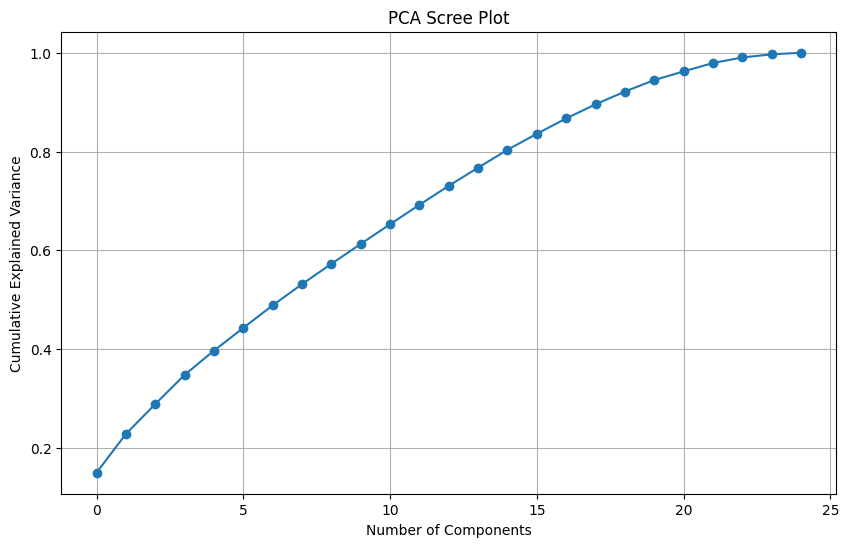

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25
0,-2.484044,0.336370,-0.527804,0.755422,-0.560286,-0.353305,-0.098070,0.370180,-0.164700,-0.948979,...,-0.351360,-0.668101,-1.176399,0.943834,-0.170449,-1.438091,-0.867701,0.148274,0.053534,-0.039242
1,1.063390,-1.468103,-0.819315,-1.204937,1.472453,-2.570311,-0.067078,-0.317249,-0.647202,-1.016320,...,0.273722,0.900488,-0.091344,0.478691,0.839535,0.901965,-0.489957,0.522146,0.016596,0.007645
2,0.974144,-1.798545,-2.192213,-0.357898,2.122550,0.057966,-0.166637,-0.583796,0.610876,-1.122107,...,0.383182,-1.414164,1.782024,1.632602,0.686530,-1.751329,0.608856,0.276426,-0.114981,-0.001975
3,-2.386790,0.157628,-0.889677,3.574973,1.483479,-0.994292,-0.084423,-0.123746,-0.742252,-0.610605,...,0.408653,-0.390192,-1.355178,0.978266,-0.766694,1.014824,1.506343,-0.415406,-0.416541,-0.052958
4,2.073621,-1.905629,0.185696,1.216683,1.045672,1.202890,1.346357,-0.996189,1.204054,-0.533932,...,0.849402,0.486905,0.715412,0.673916,0.320301,-0.345259,0.049140,0.006003,-0.111607,-0.017684


In [29]:
# -----------------------------
# 1. Copy dataframe
# -----------------------------
df_pca = df.copy()

# -----------------------------
# 2. Impute missing values (Weather2 is numeric ordinal)
# -----------------------------
df_pca['WEATHER2'] = df_pca['WEATHER2'].fillna(df_pca['WEATHER2'].median())

# -----------------------------
# 3. Scale all features
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# -----------------------------
# 4. Fit PCA
# -----------------------------
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# -----------------------------
# 5. Explained variance plot
# -----------------------------
plt.figure(figsize=(10,6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Scree Plot')
plt.grid(True)
plt.show()

# -----------------------------
# 6. Create PCA dataframe
# -----------------------------
pca_cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca_components = pd.DataFrame(X_pca, columns=pca_cols)

df_pca_components.head()


In [30]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns,   # or your encoded feature names
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

loadings


,MAX_SEVERITY_LEVEL,FATAL_COUNT,INJURY_COUNT,TOTAL_UNITS,PERSON_COUNT,CRASH_MONTH,DAY_OF_WEEK,COUNTY,URBAN_RURAL,ROAD_CONDITION,...,SINGLE_VEHICLE,REAR_END,HIT_FIXED_OBJECT,HIT_DEER,AGGRESSIVE_DRIVING,DISTRACTED,SPEEDING,IMPAIRED_DRIVER,YOUNG_DRIVER,MATURE_DRIVER
PC1,-0.113522,0.010283,-0.170453,-0.417756,-0.318877,0.002661,-0.012965,-0.013564,-0.227902,0.043975,...,0.451401,-0.225447,0.357250,0.219613,-0.199865,-0.038956,0.015399,0.080251,-0.043602,-0.123770
PC2,-0.092091,-0.039308,-0.049275,0.127974,0.108330,0.128983,-0.001567,0.009673,-0.014253,-0.102981,...,-0.122798,0.093320,-0.396091,0.593083,-0.154046,-0.001578,-0.143860,-0.174679,-0.050003,0.073141
PC3,-0.155717,-0.007938,-0.189026,0.118491,-0.047761,-0.023476,0.000123,-0.072772,0.062282,-0.063653,...,-0.065926,0.449593,0.008462,-0.116509,-0.366313,0.451679,-0.108236,0.113282,-0.045021,-0.086317
PC4,0.601161,0.043685,0.604643,0.006225,0.136488,0.027050,-0.013142,0.160472,-0.046400,-0.013648,...,0.114844,-0.009023,0.039850,0.062543,-0.213563,0.014280,0.037067,0.176012,-0.192132,-0.005130
PC5,0.049046,-0.212713,-0.104262,-0.092807,-0.201450,-0.042332,-0.045084,0.043181,0.373835,0.088485,...,0.060348,-0.170083,0.017360,-0.031511,-0.206821,0.088904,-0.325196,-0.071517,-0.257966,0.050572
PC6,0.026792,0.085672,0.009201,-0.004461,-0.074529,0.037343,0.017489,-0.140474,-0.051762,-0.244781,...,-0.015922,-0.070705,0.010800,-0.080528,-0.226111,0.163520,-0.263663,0.168655,-0.427617,0.434754
PC7,-0.159515,0.490162,-0.108614,0.044112,-0.047092,0.078851,0.011087,-0.090575,0.170540,-0.285240,...,-0.031760,-0.047824,-0.053742,0.066411,0.069054,-0.109651,0.418124,0.457940,-0.211639,0.010445
PC8,-0.114950,0.262794,-0.139310,0.107539,-0.035061,-0.156996,0.059828,0.356096,-0.062343,0.447709,...,-0.077304,0.011993,-0.077292,-0.032791,0.065400,-0.321303,-0.113132,0.023155,-0.377662,0.233296
PC9,0.075907,0.073109,0.067808,0.010778,0.039630,-0.007443,0.057777,-0.455740,0.105009,0.234101,...,0.006465,0.022937,-0.030780,0.093523,-0.077761,0.194318,0.178973,0.165204,0.014793,-0.126740
PC10,0.021001,-0.158760,0.023653,-0.072660,0.002884,0.084426,-0.451896,-0.436522,-0.110370,-0.044290,...,0.029851,0.052301,0.067642,-0.017580,0.229388,-0.061020,0.197011,-0.283764,-0.173346,0.473062


In [31]:
abs_loadings = loadings.T.abs()
top_features = abs_loadings.nlargest(10, 'PC1')
top_features


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25
SINGLE_VEHICLE,0.451401,0.122798,0.065926,0.114844,0.060348,0.015922,0.031760,0.077304,0.006465,0.029851,...,0.034004,0.021076,0.000472,0.247247,0.066297,0.069798,0.107028,0.253485,0.765320,0.096861
TOTAL_UNITS,0.417756,0.127974,0.118491,0.006225,0.092807,0.004461,0.044112,0.107539,0.010778,0.072660,...,0.007084,0.061077,0.065041,0.106948,0.257039,0.273976,0.003970,0.757393,0.142454,0.017434
HIT_FIXED_OBJECT,0.357250,0.396091,0.008462,0.039850,0.017360,0.010800,0.053742,0.077292,0.030780,0.067642,...,0.021491,0.026410,0.039815,0.276126,0.087805,0.029329,0.156572,0.485937,0.581761,0.036337
PERSON_COUNT,0.318877,0.108330,0.047761,0.136488,0.201450,0.074529,0.047092,0.035061,0.039630,0.002884,...,0.179284,0.145425,0.412368,0.520210,0.075554,0.016647,0.468026,0.181291,0.012710,0.002677
COLLISION_TYPE,0.259450,0.559867,0.142475,0.071338,0.011488,0.073239,0.064714,0.034313,0.093351,0.021066,...,0.030206,0.055327,0.005710,0.027529,0.125304,0.040265,0.042113,0.119620,0.054434,0.721599
URBAN_RURAL,0.227902,0.014253,0.062282,0.046400,0.373835,0.051762,0.170540,0.062343,0.105009,0.110370,...,0.490679,0.405461,0.068171,0.428557,0.267087,0.028646,0.040627,0.022596,0.009642,0.003053
REAR_END,0.225447,0.093320,0.449593,0.009023,0.170083,0.070705,0.047824,0.011993,0.022937,0.052301,...,0.107561,0.239139,0.537310,0.238936,0.240220,0.430985,0.028592,0.100397,0.033948,0.054351
HIT_DEER,0.219613,0.593083,0.116509,0.062543,0.031511,0.080528,0.066411,0.032791,0.093523,0.017580,...,0.046280,0.034482,0.034360,0.025694,0.156804,0.000509,0.031610,0.109485,0.198172,0.682024
AGGRESSIVE_DRIVING,0.199865,0.154046,0.366313,0.213563,0.206821,0.226111,0.069054,0.065400,0.077761,0.229388,...,0.018079,0.185576,0.082792,0.153631,0.675549,0.187690,0.029657,0.090524,0.081158,0.003774
INJURY_COUNT,0.170453,0.049275,0.189026,0.604643,0.104262,0.009201,0.108614,0.139310,0.067808,0.023653,...,0.044963,0.031010,0.102280,0.135922,0.101837,0.108604,0.665121,0.060042,0.025304,0.006984


<b>Component - Meaning</b><br>
PC1:	        Crash Type Axis — single‑vehicle vs rear‑end<br>
PC2:	        Deer vs Fixed‑Object Axis<br>
PC3:	        Behavior Axis — distracted vs aggressive<br>
PC4:	        Severity Axis<br>
PC5:	        Urban vs Rural Speeding Axis<br>
PC6:	        Mature vs Young Driver Axis<br>
PC7:	        Impaired + Speeding Axis<br>
PC8-PC10:	Geographic + Road Condition Axes<br>
PC11-PC25:	Minor temporal, geographic, and rare‑pattern components<br>

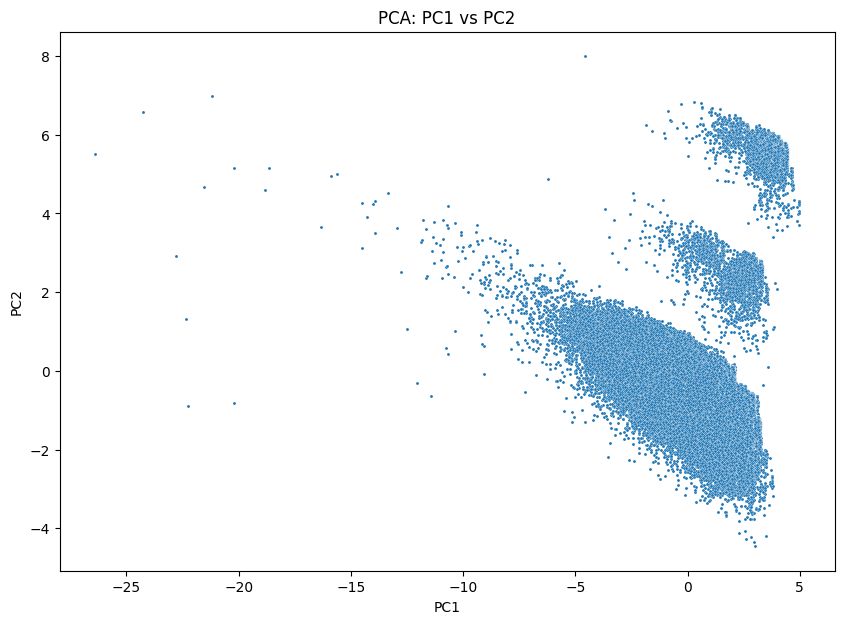

In [32]:
plt.figure(figsize=(10,7))
sns.scatterplot(x=df_pca_components['PC1'], y=df_pca_components['PC2'], s=5)
plt.title('PCA: PC1 vs PC2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


#### T-sne

In [33]:
df_sample = df_pca_components.iloc[:, :10].sample(50000, random_state=42)

from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42
)

X_tsne = tsne.fit_transform(df_sample)



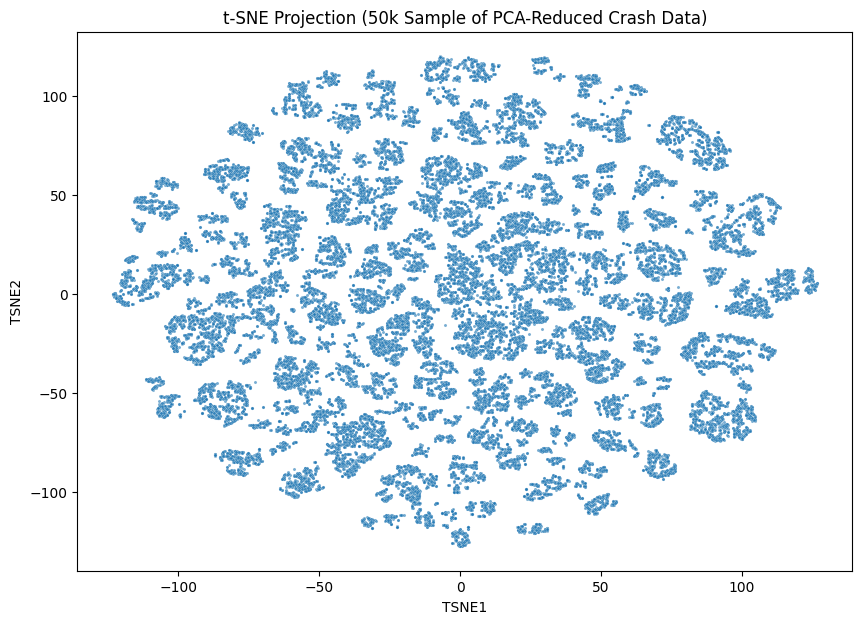

In [34]:
df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])

plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df_tsne['TSNE1'],
    y=df_tsne['TSNE2'],
    s=5,
    alpha=0.6
)
plt.title('t-SNE Projection (50k Sample of PCA-Reduced Crash Data)')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.show()

## Clustering

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 560396 entries, 0 to 560395
Data columns (total 25 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   MAX_SEVERITY_LEVEL   560396 non-null  int64  
 1   FATAL_COUNT          560396 non-null  int64  
 2   INJURY_COUNT         560396 non-null  int64  
 3   TOTAL_UNITS          560396 non-null  int64  
 4   PERSON_COUNT         560396 non-null  int64  
 5   CRASH_MONTH          560396 non-null  int64  
 6   DAY_OF_WEEK          560396 non-null  int64  
 7   COUNTY               560396 non-null  int64  
 8   URBAN_RURAL          560396 non-null  int64  
 9   ROAD_CONDITION       560396 non-null  int64  
 10  WEATHER2             283714 non-null  float64
 11  COLLISION_TYPE       560396 non-null  int64  
 12  INTERSECT_TYPE       560396 non-null  int64  
 13  SIGNALIZED_INT       560396 non-null  int64  
 14  STOP_CONTROLLED_INT  560396 non-null  int64  
 15  SINGLE_VEHICLE       560396 

In [36]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(df.sample(56000, random_state=42))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)


### K-Means

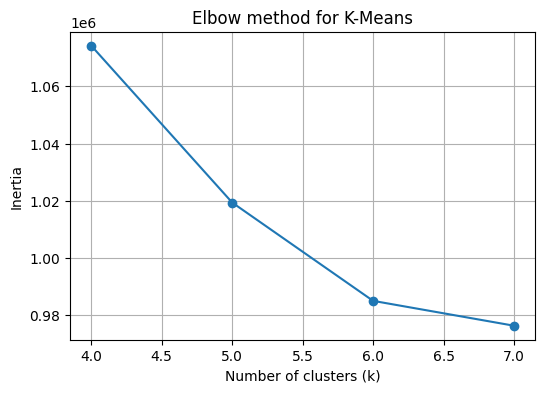

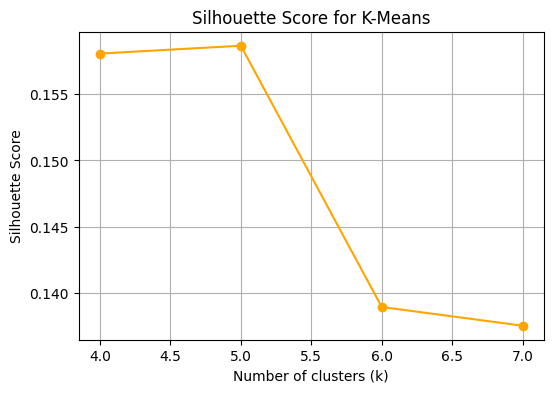

In [37]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_cluster = df_pca_components.iloc[:, :10]

inertias = []
silhouette_scores = []
k_values = range(4, 8)

for k in k_values:
    km = KMeans(
        n_clusters= k,
        init = 'k-means++',
        n_init = 'auto', 
        random_state = 42
    )
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6, 4))
plt.plot(k_values, inertias, marker = 'o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow method for K-Means')
plt.grid(True)
plt.show()

plt.figure(figsize = (6, 4))
plt.plot(k_values, silhouette_scores, marker = 'o', color = 'orange')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for K-Means')
plt.grid(True)
plt.show()

In [38]:
from sklearn.cluster import KMeans

X_cluster = df_pca_components.iloc[:, :10]

kmeans = KMeans(n_clusters=6, random_state=42)
labels_kmeans = kmeans.fit_predict(X_cluster)

df_clusters = df.copy()
df_clusters['cluster_kmeans'] = labels_kmeans


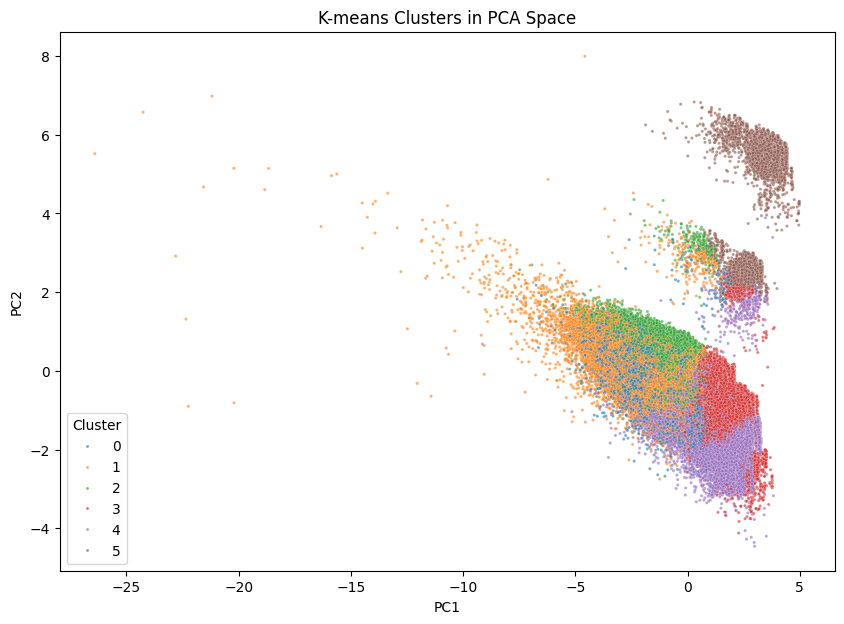

In [39]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df_pca_components['PC1'],
    y=df_pca_components['PC2'],
    hue=df_clusters['cluster_kmeans'],
    palette='tab10',
    s=5,
    alpha=0.6
)
plt.title('K-means Clusters in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.show()


### DBSCAN

In [40]:
from sklearn.cluster import DBSCAN

# Try a few eps values to find a reasonable one
eps_values = [0.3, 0.5, 0.7, 1.0]
min_samples = 5

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters > 1:
        score = silhouette_score(X_scaled, labels)
        print(f"eps={eps}, clusters={n_clusters}, silhouette={score:.3f}")
    else:
        print(f"eps={eps}, clusters={n_clusters}, silhouette=N/A")


eps=0.3, clusters=200, silhouette=-0.466
eps=0.5, clusters=469, silhouette=-0.492
eps=0.7, clusters=514, silhouette=-0.433
eps=1.0, clusters=500, silhouette=-0.286


In [41]:
#from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.3,
    min_samples=100
)

labels_dbscan = dbscan.fit_predict(X_cluster)
df_clusters['cluster_dbscan'] = labels_dbscan


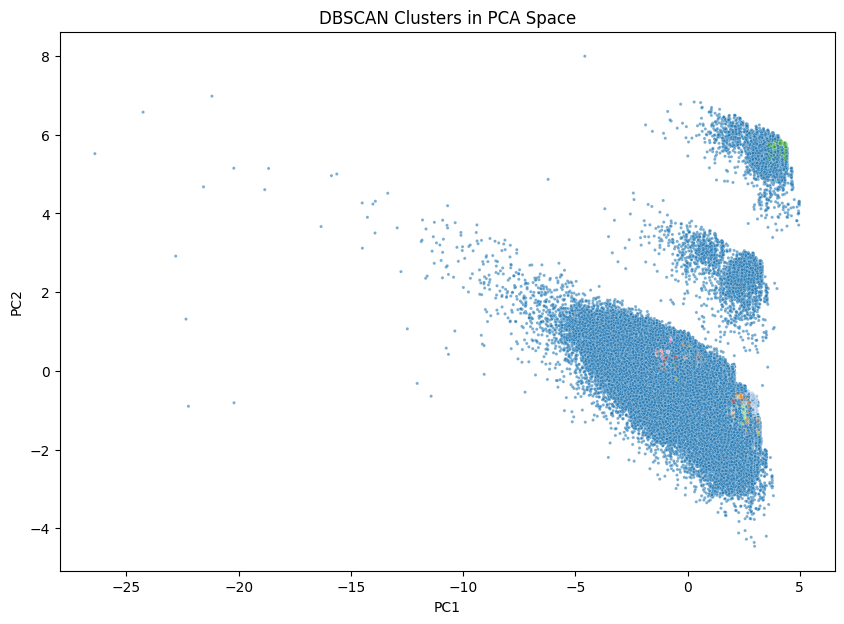

In [42]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df_pca_components['PC1'],
    y=df_pca_components['PC2'],
    hue=df_clusters['cluster_dbscan'],
    palette='tab20',
    s=5,
    alpha=0.6,
    legend=False
)
plt.title('DBSCAN Clusters in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


## Outlier Detection

### GMM on PCA components

In [43]:
from sklearn.mixture import GaussianMixture

df_outliers = df_pca_components.copy()   # or df_pca_components.copy(), depending on what you want



X_gmm = df_pca_components.iloc[:, :10]

gmm = GaussianMixture(
    n_components=8,
    covariance_type='full',
    random_state=42
)

gmm.fit(X_gmm)
log_probs = gmm.score_samples(X_gmm)

df_outliers['outlier_gmm'] = (log_probs < np.percentile(log_probs, 1)).astype(int)


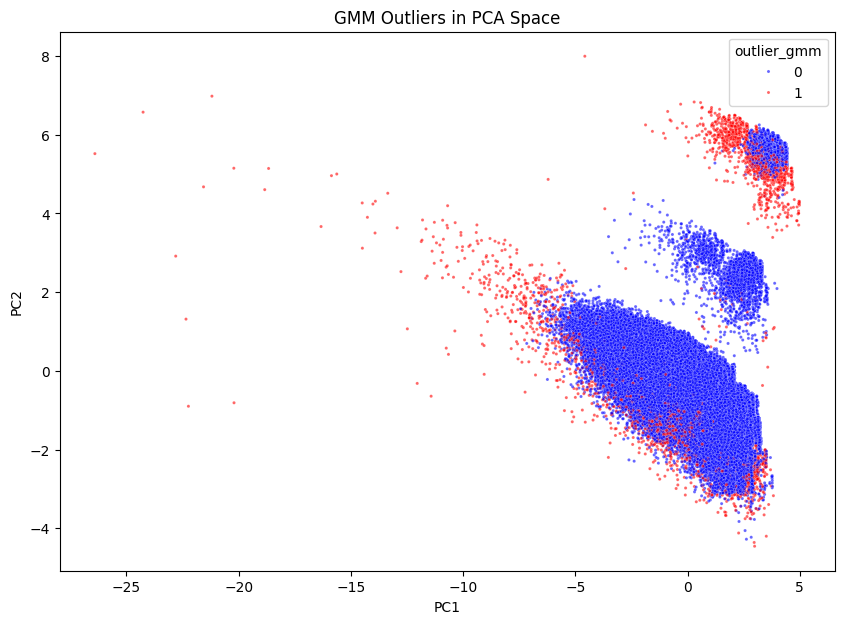

In [44]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df_pca_components['PC1'],
    y=df_pca_components['PC2'],
    hue=df_outliers['outlier_gmm'],
    palette={0:'blue', 1:'red'},
    s=5,
    alpha=0.6
)
plt.title('GMM Outliers in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()


### Isolation Forest

In [46]:
from sklearn.ensemble import IsolationForest

# Use first 10 PCA components for outlier detection
X_if = df_pca_components.iloc[:, :10]

iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,   # flag ~1% as outliers
    random_state=42
)

iso_labels = iso.fit_predict(X_if)

df_outliers = df.copy()
df_outliers['outlier_iso'] = iso_labels  # -1 = outlier, 1 = normal


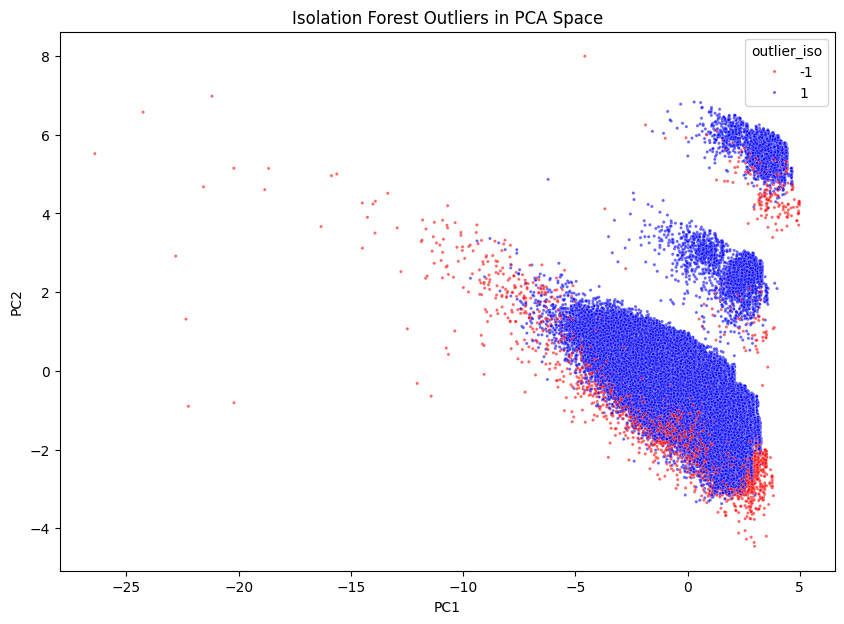

In [47]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    x=df_pca_components['PC1'],
    y=df_pca_components['PC2'],
    hue=df_outliers['outlier_iso'],
    palette={1:'blue', -1:'red'},
    s=5,
    alpha=0.6
)
plt.title('Isolation Forest Outliers in PCA Space')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()
